# 04 Resultados y predicciones

Objetivo: generar las predicciones finales y preparar archivos para decision.

Salidas:

- predicciones PT,
- predicciones PP,
- Excel final con dos hojas,
- plantilla de validacion experta,
- plantilla de stock actual, stock minimo y stock maximo.
- plantillas de variables exogenas calendario/producto,
- rangos de decision: minimo, maximo, confianza y revision.

Las predicciones usan el modelo ML mas estable entre validacion y test cuando `forecast_model` esta configurado como `best_ml_stable`.

In [1]:
from pathlib import Path
import sys
from io import StringIO

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "config" / "config.yml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto. Abre VS Code en la carpeta 'Avance 3'.")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)
plt.style.use("default")

from quickbooks_forecast.config import load_config

config = load_config()
reports_dir = config["resolved_paths"]["reports_dir"]
processed_dir = config["resolved_paths"]["processed_dir"]
raw_dir = config["resolved_paths"]["raw_dir"]
images_dir = ROOT / "notebooks" / "images"
images_dir.mkdir(parents=True, exist_ok=True)

def save_fig(name, extension="png", resolution=160):
    path_final = images_dir / f"{name}.{extension}"
    plt.tight_layout()
    plt.savefig(path_final, dpi=resolution, bbox_inches="tight")
    print(f"Figura guardada: {path_final}")

**Preparacion de predicciones finales:**

Este bloque prepara el entorno final para generar predicciones y reportes usando los modelos entrenados.

In [2]:
from quickbooks_forecast.modeling import predict_all
from quickbooks_forecast.decision import build_decision_templates

predictions = predict_all(config)
decision_outputs = build_decision_templates(config)

print("PT:", predictions["PT"].shape)
print("PP:", predictions["PP"].shape)

C:\Users\Tony\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PT: (9450, 48)
PP: (2532, 48)


**Generacion de salidas PT y PP:**

Aqui se generan las dos tablas finales solicitadas: predicciones para PT y predicciones para PP. Tambien se crean plantillas de apoyo para decision operativa.

In [3]:
exog_report = reports_dir / "exogenous_variables_plan.md"
if exog_report.exists():
    display(Markdown(exog_report.read_text(encoding="utf-8")))

demo_report = reports_dir / "variables_exogenas_ecuador_demo.md"
if demo_report.exists():
    display(Markdown(demo_report.read_text(encoding="utf-8")))

replacement_results = reports_dir / "exogenous_replacement_results.md"
if replacement_results.exists():
    display(Markdown(replacement_results.read_text(encoding="utf-8")))

replacement_report = reports_dir / "replacement_readiness.md"
if replacement_report.exists():
    display(Markdown(replacement_report.read_text(encoding="utf-8")))

# Plan de variables exogenas

## Archivos de entrada

- `data/input/variables_exogenas_calendario.csv`: variables conocidas por mes y tipo PT/PP.
- `data/input/variables_exogenas_producto.csv`: variables conocidas por producto y mes.
- Las plantillas equivalentes terminan en `_template.csv`.

## Regla contra fuga de informacion

Cada valor debe ser conocido antes de iniciar el mes que se quiere predecir. No uses cantidades reales vendidas, fabricadas o informacion calculada despues del cierre del mes como variable exogena de ese mismo mes.

## Variables generales por mes

dias_laborables, feriados_mes, promocion_general, temporada_alta_general, evento_comercial, variacion_precio_general_pct

## Variables por producto y mes

pedidos_confirmados, preventa_confirmada, promocion_producto, cliente_grande_confirmado, cambio_pvp_pct, precio_planificado, riesgo_quiebre_stock, disponibilidad_materia_prima, ajuste_comercial_manual

## Estado actual de captura

- Filas calendario con informacion no cero: 72
- Filas producto con informacion no cero: 46476

## Como medir la mejora

1. Completar historico real de variables exogenas para los meses de train, validacion y test.
2. Completar variables futuras conocidas para el horizonte de prediccion.
3. Ejecutar `python3 -B scripts/run_all.py`.
4. Comparar `reports/model_comparison_all.csv` contra la version anterior.


**Evidencia conceptual y exogenas:**

Este bloque documenta la parte conceptual: que variables exogenas se usaron, por que bajan el error y por que el escenario asistido no debe confundirse con validacion oficial sin datos reales.

In [4]:
pred_pt = pd.read_csv(reports_dir / "predicciones_pt.csv")
pred_pp = pd.read_csv(reports_dir / "predicciones_pp.csv")

print("Modelo usado PT")
display(pred_pt["modelo_usado"].value_counts().reset_index())
print("Modelo usado PP")
display(pred_pp["modelo_usado"].value_counts().reset_index())

display(pred_pt.head(20))
display(pred_pp.head(20))

Modelo usado PT


,modelo_usado,count
0,random_forest,8851
1,inactive_zero_rule,599


Modelo usado PP


,modelo_usado,count
0,random_forest,2412
1,inactive_zero_rule,120


,source_type,product_id,product_name,periodo,anio,mes,cantidad_predicha,estado_producto,es_estacional,meses_estacionales,ultima_actividad,modelo_usado,ultimo_periodo_entrenamiento,error_absoluto_total,wape_producto,prioridad_revision,segmento_operativo,segmento_apto_automatizacion,wape_segmento_walk_forward,std_wape_segmento_walk_forward,pct_folds_below_wape_threshold,riesgo_confianza_base,riesgo_confianza_ajustado,error_relativo_estimado,prediccion_min,prediccion_max,confianza_prediccion,requiere_revision,cumple_confianza_minima,apto_automatizacion,cantidad_sugerida_sin_inventario,recomendacion_decision,stock_actual,stock_encontrado,stock_match_status,stock_item,stock_item_description,stock_fecha_referencia,stock_avg_cost,stock_asset_value,stock_minimo,stock_maximo,stock_proyectado_inicio,stock_proyectado_fin,cantidad_a_producir_ajustada,alerta_inventario,valor_stock_actual,valor_produccion_ajustada
0,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-04-01,2026,4,5.75,activo,False,"enero, octubre, julio",2026-03-01,random_forest,2026-03-01,2.443733,0.122187,normal,activos_no_estacionales,True,0.066526,0.004994,1.0,0.12,0.12,0.12,5.05,6.45,media,False,True,True,5.75,usar como cantidad sugerida,8.0,True,item_path_vs_item,PT:1 CONDIMENSA:CONDIMENTOS EN POLVO:SAZONADOR...,SAZONADOR AZAFRAN KILO (0000),2026-01-19,4.89,39.10,0.0,NaN,8.00,2.25,0.00,dentro_rango,39.12,0.00
1,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-04-01,2026,4,5.75,activo,False,"enero, octubre, julio",2026-03-01,random_forest,2026-03-01,0.442397,0.055300,normal,activos_no_estacionales,True,0.066526,0.004994,1.0,0.07,0.07,0.07,5.34,6.16,alta,False,True,True,5.75,usar como cantidad sugerida,8.0,True,item_path_vs_item,PT:1 CONDIMENSA:CONDIMENTOS EN POLVO:SAZONADOR...,SAZONADOR AZAFRAN KILO (0000),2026-01-19,4.89,39.10,0.0,NaN,2.25,0.00,3.50,dentro_rango,39.12,17.11
2,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-05-01,2026,5,5.76,activo,False,"enero, octubre, julio",2026-04-01,random_forest,2026-03-01,2.443733,0.122187,normal,activos_no_estacionales,True,0.066526,0.004994,1.0,0.12,0.12,0.12,5.06,6.46,media,False,True,True,5.76,usar como cantidad sugerida,8.0,True,item_path_vs_item,PT:1 CONDIMENSA:CONDIMENTOS EN POLVO:SAZONADOR...,SAZONADOR AZAFRAN KILO (0000),2026-01-19,4.89,39.10,0.0,NaN,0.00,0.00,5.76,dentro_rango,39.12,28.17
3,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-05-01,2026,5,5.76,activo,False,"enero, octubre, julio",2026-04-01,random_forest,2026-03-01,0.442397,0.055300,normal,activos_no_estacionales,True,0.066526,0.004994,1.0,0.07,0.07,0.07,5.35,6.17,alta,False,True,True,5.76,usar como cantidad sugerida,8.0,True,item_path_vs_item,PT:1 CONDIMENSA:CONDIMENTOS EN POLVO:SAZONADOR...,SAZONADOR AZAFRAN KILO (0000),2026-01-19,4.89,39.10,0.0,NaN,0.00,0.00,5.76,dentro_rango,39.12,28.17
4,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-06-01,2026,6,0.86,activo,False,"enero, octubre, julio",2026-05-01,random_forest,2026-03-01,2.443733,0.122187,normal,activos_no_estacionales,True,0.066526,0.004994,1.0,0.12,0.12,0.12,0.75,0.97,media,False,True,True,0.86,usar como cantidad sugerida,8.0,True,item_path_vs_item,PT:1 CONDIMENSA:CONDIMENTOS EN POLVO:SAZONADOR...,SAZONADOR AZAFRAN KILO (0000),2026-01-19,4.89,39.10,0.0,NaN,0.00,0.00,0.86,dentro_rango,39.12,4.21
5,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-06-01,2026,6,0.86,activo,False,"enero, octubre, julio",2026-05-01,random_forest,2026-03-01,0.442397,0.055300,normal,activos_no_estacionales,True,0.066526,0.004994,1.0,0.07,0.07,0.07,0.80,0.92,alta,False,True,True,0.86,usar como cantidad sugerida,8.0,True,item_path_vs_item,PT:1 CONDIMENSA:CONDIMENTOS EN POLVO:SAZONADOR...,SAZONADOR AZAFRAN KILO (0000),2026-01-19,4.89,39.10,0.0,NaN,0.00,0.00,0.86,dentro_rango,39.12,4.21
6,PT,PT_0000,SAZONADOR AZAFRAN KILO (0000),2026-07-01,2026,7,1.36,activo,False,"enero, octubre, julio",2026-06-01,random_forest,2026-03-01,2.443733,0.122187,normal,activos_no_estacionales,True,0.066526,0.004994,1.0,0.12,0.12,0.12,1.19,1.53,media,False,True,Tru

,source_type,product_id,product_name,periodo,anio,mes,cantidad_predicha,estado_producto,es_estacional,meses_estacionales,ultima_actividad,modelo_usado,ultimo_periodo_entrenamiento,error_absoluto_total,wape_producto,prioridad_revision,segmento_operativo,segmento_apto_automatizacion,wape_segmento_walk_forward,std_wape_segmento_walk_forward,pct_folds_below_wape_threshold,riesgo_confianza_base,riesgo_confianza_ajustado,error_relativo_estimado,prediccion_min,prediccion_max,confianza_prediccion,requiere_revision,cumple_confianza_minima,apto_automatizacion,cantidad_sugerida_sin_inventario,recomendacion_decision,stock_actual,stock_encontrado,stock_match_status,stock_item,stock_item_description,stock_fecha_referencia,stock_avg_cost,stock_asset_value,stock_minimo,stock_maximo,stock_proyectado_inicio,stock_proyectado_fin,cantidad_a_producir_ajustada,alerta_inventario,valor_stock_actual,valor_produccion_ajustada
0,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2026-03-01,2026,3,6047.87,activo,False,"enero, septiembre, agosto",2026-02-01,random_forest,2026-02-01,442.218141,0.054336,normal,activos_no_estacionales,True,0.059937,0.005214,1.000000,0.07,0.07,0.07,5653.84,6441.90,alta,False,True,True,6047.87,usar como cantidad sugerida,99.20196,True,product_norm_vs_item,PP:MOSTAZA PRODUCCIÓN GRANEL,*MOSTAZA PRODUCCIÓN GRANEL,2026-02-25,0.88,86.98,0.0,NaN,99.20,0.0,5948.67,dentro_rango,87.30,5234.83
1,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2026-03-01,2026,3,6047.87,activo,False,"enero, septiembre, agosto",2026-02-01,random_forest,2026-02-01,223.484765,0.046061,normal,activos_no_estacionales,True,0.059937,0.005214,1.000000,0.07,0.07,0.07,5653.84,6441.90,alta,False,True,True,6047.87,usar como cantidad sugerida,99.20196,True,product_norm_vs_item,PP:MOSTAZA PRODUCCIÓN GRANEL,*MOSTAZA PRODUCCIÓN GRANEL,2026-02-25,0.88,86.98,0.0,NaN,0.00,0.0,6047.87,dentro_rango,87.30,5322.13
2,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2026-03-01,2026,3,6047.87,activo,False,"enero, septiembre, agosto",2026-02-01,random_forest,2026-02-01,203.605446,0.020931,normal,activos_no_estacionales,True,0.059937,0.005214,1.000000,0.07,0.07,0.07,5653.84,6441.90,alta,False,True,True,6047.87,usar como cantidad sugerida,99.20196,True,product_norm_vs_item,PP:MOSTAZA PRODUCCIÓN GRANEL,*MOSTAZA PRODUCCIÓN GRANEL,2026-02-25,0.88,86.98,0.0,NaN,0.00,0.0,6047.87,dentro_rango,87.30,5322.13
3,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2026-04-01,2026,4,7627.35,activo,False,"enero, septiembre, agosto",2026-03-01,random_forest,2026-02-01,442.218141,0.054336,normal,activos_no_estacionales,True,0.059937,0.005214,1.000000,0.07,0.07,0.07,7130.42,8124.28,alta,False,True,True,7627.35,usar como cantidad sugerida,99.20196,True,product_norm_vs_item,PP:MOSTAZA PRODUCCIÓN GRANEL,*MOSTAZA PRODUCCIÓN GRANEL,2026-02-25,0.88,86.98,0.0,NaN,0.00,0.0,7627.35,dentro_rango,87.30,6712.07
4,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2026-04-01,2026,4,7627.35,activo,False,"enero, septiembre, agosto",2026-03-01,random_forest,2026-02-01,223.484765,0.046061,normal,activos_no_estacionales,True,0.059937,0.005214,1.000000,0.07,0.07,0.07,7130.42,8124.28,alta,False,True,True,7627.35,usar como cantidad sugerida,99.20196,True,product_norm_vs_item,PP:MOSTAZA PRODUCCIÓN GRANEL,*MOSTAZA PRODUCCIÓN GRANEL,2026-02-25,0.88,86.98,0.0,NaN,0.00,0.0,7627.35,dentro_rango,87.30,6712.07
5,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2026-04-01,2026,4,7627.35,activo,False,"enero, septiembre, agosto",2026-03-01,random_forest,2026-02-01,203.605446,0.020931,normal,activos_no_estacionales,True,0.059937,0.005214,1.000000,0.07,0.07,0.07,7130.42,8124.28,alta,False,True,True,7627.35,usar como cantidad sugerida,99.20196,True,product_norm_vs_item,PP:MOSTAZA PRODUCCIÓN GRANEL,*MOSTAZA PRODUCCIÓN GRANEL,2026-02-25,0.88,86.98,0.0,NaN,0.00,0.0,7627.35,dentro_rango,87.30,6712.07
6,PP,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,2026-05-01,2026,5,3597.15,activo,False,"enero, septiembre, agosto",2026-04-01,random_forest,2026-02-01,223.484765,0.046061,normal,activo

**Revision de tablas finales:**

Las predicciones finales incluyen el modelo usado y los campos de confianza. Estas tablas son la salida que podria revisar produccion cada mes.

,source_type,periodo,modelo_usado,productos,cantidad_predicha
0,PP,2026-03-01,inactive_zero_rule,20,0.00
1,PP,2026-03-01,random_forest,218,5664682.76
2,PP,2026-04-01,inactive_zero_rule,20,0.00
3,PP,2026-04-01,random_forest,218,3820898.65
4,PP,2026-05-01,inactive_zero_rule,20,0.00
5,PP,2026-05-01,random_forest,218,2306028.27
6,PP,2026-06-01,inactive_zero_rule,20,0.00
7,PP,2026-06-01,random_forest,218,1032223.25
8,PP,2026-07-01,inactive_zero_rule,20,0.00
9,PP,2026-07-01,random_forest,218,2323664.86


Figura guardada: F:\proyecto-integrador\Avance 3\Modelado\forecasting_v3\notebooks\images\04_prediccion_mensual_total.png


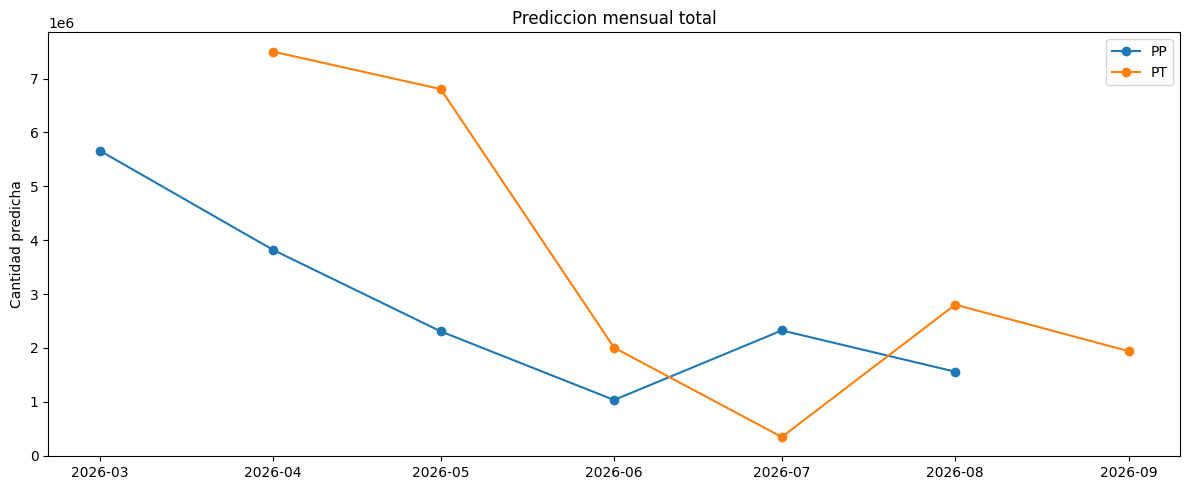

In [5]:
resumen_pred = pd.concat([pred_pt, pred_pp], ignore_index=True)
resumen = (
    resumen_pred.groupby(["source_type", "periodo", "modelo_usado"], as_index=False)
    .agg(productos=("product_id", "nunique"), cantidad_predicha=("cantidad_predicha", "sum"))
)
display(resumen)

fig, ax = plt.subplots(figsize=(12, 5))
for source, group in resumen_pred.groupby("source_type"):
    mensual = group.groupby("periodo")["cantidad_predicha"].sum()
    ax.plot(pd.to_datetime(mensual.index), mensual.values, marker="o", label=source)
ax.set_title("Prediccion mensual total")
ax.set_ylabel("Cantidad predicha")
ax.legend()
save_fig("04_prediccion_mensual_total")
plt.show()

**Lectura mensual agregada:**

El resumen mensual ayuda a ver la carga total esperada para PT y PP. Sirve como primera lectura gerencial antes de bajar al detalle por producto.

In [6]:
print("Top PT por cantidad predicha")
display(pred_pt.sort_values("cantidad_predicha", ascending=False).head(30))

print("Top PP por cantidad predicha")
display(pred_pp.sort_values("cantidad_predicha", ascending=False).head(30))

Top PT por cantidad predicha


,source_type,product_id,product_name,periodo,anio,mes,cantidad_predicha,estado_producto,es_estacional,meses_estacionales,ultima_actividad,modelo_usado,ultimo_periodo_entrenamiento,error_absoluto_total,wape_producto,prioridad_revision,segmento_operativo,segmento_apto_automatizacion,wape_segmento_walk_forward,std_wape_segmento_walk_forward,pct_folds_below_wape_threshold,riesgo_confianza_base,riesgo_confianza_ajustado,error_relativo_estimado,prediccion_min,prediccion_max,confianza_prediccion,requiere_revision,cumple_confianza_minima,apto_automatizacion,cantidad_sugerida_sin_inventario,recomendacion_decision,stock_actual,stock_encontrado,stock_match_status,stock_item,stock_item_description,stock_fecha_referencia,stock_avg_cost,stock_asset_value,stock_minimo,stock_maximo,stock_proyectado_inicio,stock_proyectado_fin,cantidad_a_producir_ajustada,alerta_inventario,valor_stock_actual,valor_produccion_ajustada
4998,PT,PT_4841,EL ARTESANAL ACEITE GIRASOL 1L (4841),2026-04-01,2026,4,75006.37,activo,False,"diciembre, enero, noviembre",2026-03-01,random_forest,2026-03-01,11985.181689,0.125702,alta,activos_no_estacionales,True,0.066526,0.004994,1.0,0.13,0.14,0.14,64827.86,85184.88,media,True,True,False,75006.37,revisar antes de ordenar,3773.0,True,item_path_vs_item,PT:MAQUILA:MAQUILA SUPERMAXI:EL ARTESANAL:EL A...,EL ARTESANAL ACEITE GIRASOL 1L (4841),2026-02-25,1.58,5973.87,0.0,NaN,3773.0,0.0,71233.37,dentro_rango,5961.34,112548.72
4999,PT,PT_4841,EL ARTESANAL ACEITE GIRASOL 1L (4841),2026-04-01,2026,4,75006.37,activo,False,"diciembre, enero, noviembre",2026-03-01,random_forest,2026-03-01,8191.033833,0.069096,alta,activos_no_estacionales,True,0.066526,0.004994,1.0,0.07,0.08,0.08,68891.86,81120.88,alta,True,True,False,75006.37,revisar antes de ordenar,3773.0,True,item_path_vs_item,PT:MAQUILA:MAQUILA SUPERMAXI:EL ARTESANAL:EL A...,EL ARTESANAL ACEITE GIRASOL 1L (4841),2026-02-25,1.58,5973.87,0.0,NaN,0.0,0.0,75006.37,dentro_rango,5961.34,118510.06
3600,PT,PT_3058,EL ARTESANAL ACEITE VEGETAL 1L (3058),2026-04-01,2026,4,74781.84,activo,False,"septiembre, noviembre, julio",2026-03-01,random_forest,2026-03-01,9582.198789,0.068890,alta,activos_no_estacionales,True,0.066526,0.004994,1.0,0.07,0.08,0.08,68685.63,80878.05,alta,True,True,False,74781.84,revisar antes de ordenar,36272.0,True,item_path_vs_item,PT:MAQUILA:MAQUILA SUPERMAXI:EL ARTESANAL:EL A...,EL ARTESANAL ACEITE VEGETAL 1L (3058),2026-02-25,1.34,48473.81,0.0,NaN,36272.0,0.0,38509.84,dentro_rango,48604.48,51603.19
3601,PT,PT_3058,EL ARTESANAL ACEITE VEGETAL 1L (3058),2026-04-01,2026,4,74781.84,activo,False,"septiembre, noviembre, julio",2026-03-01,random_forest,2026-03-01,2680.411655,0.043504,alta,activos_no_estacionales,True,0.066526,0.004994,1.0,0.07,0.08,0.08,68685.63,80878.05,alta,True,True,False,74781.84,revisar antes de ordenar,36272.0,True,item_path_vs_item,PT:MAQUILA:MAQUILA SUPERMAXI:EL ARTESANAL:EL A...,EL ARTESANAL ACEITE VEGETAL 1L (3058),2026-02-25,1.34,48473.81,0.0,NaN,0.0,0.0,74781.84,dentro_rango,48604.48,100207.67
145,PT,PT_0077,CANELA RAMA FDA 30 GRS(0077),2026-04-01,2026,4,73723.91,activo,False,"diciembre, marzo, enero",2026-03-01,random_forest,2026-03-01,3572.102163,0.072133,alta,activos_no_estacionales,True,0.066526,0.004994,1.0,0.07,0.08,0.08,67668.74,79779.08,alta,True,True,False,73723.91,revisar antes de ordenar,11423.0,True,item_path_vs_item,PT:1 CONDIMENSA:ESPECIAS Y DESHIDRATADOS:CANEL...,CANELA RAMA FDA 30 GRS(0077),2026-02-27,0.57,6540.81,0.0,NaN,0.0,0.0,73723.91,dentro_rango,6511.11,42022.63
146,PT,PT_0077,CANELA RAMA FDA 30 GRS(0077),2026-04-01,2026,4,73723.91,activo,False,"diciembre, marzo, enero",2026-03-01,random_forest,2026-03-01,3132.829402,0.081983,alta,activos_no_estacionales,True,0.066526,0.004994,1.0,0.08,0.09,0.09,66942.54,80505.28,media,True,True,False,73723.91,revisar antes de ordenar,11423.0,True,item_path_vs_item,PT:1 CONDIMENSA:ESPECIAS Y DESHIDRATADOS:CANEL...,CANELA RAMA FDA 30 GRS(0077),2026-02-27,0.57,6540.81,0.0,NaN,0.0,0.0,73723.91,dentro_

Top PP por cantidad predicha


,source_type,product_id,product_name,periodo,anio,mes,cantidad_predicha,estado_producto,es_estacional,meses_estacionales,ultima_actividad,modelo_usado,ultimo_periodo_entrenamiento,error_absoluto_total,wape_producto,prioridad_revision,segmento_operativo,segmento_apto_automatizacion,wape_segmento_walk_forward,std_wape_segmento_walk_forward,pct_folds_below_wape_threshold,riesgo_confianza_base,riesgo_confianza_ajustado,error_relativo_estimado,prediccion_min,prediccion_max,confianza_prediccion,requiere_revision,cumple_confianza_minima,apto_automatizacion,cantidad_sugerida_sin_inventario,recomendacion_decision,stock_actual,stock_encontrado,stock_match_status,stock_item,stock_item_description,stock_fecha_referencia,stock_avg_cost,stock_asset_value,stock_minimo,stock_maximo,stock_proyectado_inicio,stock_proyectado_fin,cantidad_a_producir_ajustada,alerta_inventario,valor_stock_actual,valor_produccion_ajustada
1050,PP,PP_6bfc0c1cda,ENG ACHIOTE PASTA DP X 30(0.10),2026-03-01,2026,3,182932.17,activo,False,"agosto, octubre, noviembre",2026-02-01,random_forest,2026-02-01,17269.362575,0.035455,alta,activos_no_estacionales,True,0.059937,0.005214,1.000000,0.07,0.08,0.08,169184.55,196679.79,alta,True,True,False,182932.17,revisar antes de ordenar,40769.99873,True,product_norm_vs_item,PP:ENG ACHIOTE PASTA DP X 30(0.10),ENG ACHIOTE PASTA DP X 30(0.10)..,2026-02-27,0.03,1326.39,0.0,NaN,40770.00,0.0,142162.17,dentro_rango,1223.10,4264.87
19,PP,PP_021ba1ac93,* ALINO COMPLETO KILOS GRANEL,2026-03-01,2026,3,165044.07,activo,True,"octubre, noviembre, febrero",2026-02-01,random_forest,2026-02-01,3019.855029,0.032237,alta,activos_estacionales,False,0.117818,0.031219,0.166667,0.15,0.17,0.17,137145.54,192942.60,baja,True,False,False,165044.07,revisar antes de ordenar,325443.46532,True,product_norm_vs_item,PP:* ALINO COMPLETO KILOS GRANEL,* ALINO COMPLETO KILOS GRANEL,2026-02-26,0.58,188818.82,0.0,NaN,160399.40,0.0,4644.67,dentro_rango,188757.21,2693.91
18,PP,PP_021ba1ac93,* ALINO COMPLETO KILOS GRANEL,2026-03-01,2026,3,165044.07,activo,True,"octubre, noviembre, febrero",2026-02-01,random_forest,2026-02-01,8536.671773,0.037548,alta,activos_estacionales,False,0.117818,0.031219,0.166667,0.15,0.17,0.17,137145.54,192942.60,baja,True,False,False,165044.07,revisar antes de ordenar,325443.46532,True,product_norm_vs_item,PP:* ALINO COMPLETO KILOS GRANEL,* ALINO COMPLETO KILOS GRANEL,2026-02-26,0.58,188818.82,0.0,NaN,325443.47,160399.4,0.00,dentro_rango,188757.21,0.00
1237,PP,PP_78aa27e970,ENG EL ARTESANCALDO DE GALLINA,2026-03-01,2026,3,164114.16,activo,False,"febrero, enero, diciembre",2026-02-01,random_forest,2026-02-01,8209.113645,0.074946,alta,activos_no_estacionales,True,0.059937,0.005214,1.000000,0.07,0.08,0.08,150173.35,178054.97,alta,True,True,False,164114.16,revisar antes de ordenar,17333.98504,True,product_norm_vs_item,PP:ENG EL ARTESANCALDO DE GALLINA,ENG EL ARTESANAL CALDO DE GALLINA 8G,2026-02-23,0.02,419.11,0.0,NaN,0.00,0.0,164114.16,dentro_rango,346.68,3282.28
1238,PP,PP_78aa27e970,ENG EL ARTESANCALDO DE GALLINA,2026-03-01,2026,3,164114.16,activo,False,"febrero, enero, diciembre",2026-02-01,random_forest,2026-02-01,417.114649,0.004459,normal,activos_no_estacionales,True,0.059937,0.005214,1.000000,0.07,0.07,0.07,153421.89,174806.43,alta,False,True,True,164114.16,usar como cantidad sugerida,17333.98504,True,product_norm_vs_item,PP:ENG EL ARTESANCALDO DE GALLINA,ENG EL ARTESANAL CALDO DE GALLINA 8G,2026-02-23,0.02,419.11,0.0,NaN,0.00,0.0,164114.16,dentro_rango,346.68,3282.28
1236,PP,PP_78aa27e970,ENG EL ARTESANCALDO DE GALLINA,2026-03-01,2026,3,164114.16,activo,False,"febrero, enero, diciembre",2026-02-01,random_forest,2026-02-01,13097.134613,0.131307,alta,activos_no_estacionales,True,0.059937,0.005214,1.000000,0.13,0.14,0.14,140923.60,187304.72,media,True,True,False,164114.16,revisar antes de ordenar,17333.98504,True,product_norm_vs_item,PP:ENG EL ARTESANCALDO DE GALLINA,ENG EL ARTESANAL CALDO DE GALLINA 8G,2026-02-23,0.02,419.11,0.0,NaN,17333.99,0.0,14

**Productos criticos por volumen:**

Los productos top por cantidad predicha son los de mayor impacto operativo. Cualquier error en estos productos afecta mas al WAPE y a la produccion real.

In [7]:
validation = pd.read_csv(ROOT / "data" / "input" / "validacion_expertos_template.csv")
stock = pd.read_csv(ROOT / "data" / "input" / "stock_min_max_template.csv")

print("Plantilla validacion experta")
display(validation.head(20))

print("Plantilla stock min/max")
display(stock.head(20))

Plantilla validacion experta


,source_type,product_id,product_name,periodo,cantidad_predicha,prediccion_min,prediccion_max,confianza_prediccion,requiere_revision,recomendacion_decision,estado_producto,es_estacional,meses_estacionales,error_absoluto_total,wape_producto,prioridad_revision,criterio_experto,cantidad_ajustada_experto,motivo_ajuste,responsable_revision
0,PP,PP_6bfc0c1cda,ENG ACHIOTE PASTA DP X 30(0.10),2026-03-01,182932.17,169184.55,196679.79,alta,True,revisar antes de ordenar,activo,False,"agosto, octubre, noviembre",17269.362575,0.035455,alta,NaN,NaN,NaN,NaN
1,PP,PP_021ba1ac93,* ALINO COMPLETO KILOS GRANEL,2026-03-01,165044.07,137145.54,192942.60,baja,True,revisar antes de ordenar,activo,True,"octubre, noviembre, febrero",8536.671773,0.037548,alta,NaN,NaN,NaN,NaN
2,PP,PP_021ba1ac93,* ALINO COMPLETO KILOS GRANEL,2026-03-01,165044.07,137145.54,192942.60,baja,True,revisar antes de ordenar,activo,True,"octubre, noviembre, febrero",3019.855029,0.032237,alta,NaN,NaN,NaN,NaN
3,PP,PP_78aa27e970,ENG EL ARTESANCALDO DE GALLINA,2026-03-01,164114.16,153421.89,174806.43,alta,False,usar como cantidad sugerida,activo,False,"febrero, enero, diciembre",417.114649,0.004459,normal,NaN,NaN,NaN,NaN
4,PP,PP_78aa27e970,ENG EL ARTESANCALDO DE GALLINA,2026-03-01,164114.16,150173.35,178054.97,alta,True,revisar antes de ordenar,activo,False,"febrero, enero, diciembre",8209.113645,0.074946,alta,NaN,NaN,NaN,NaN
5,PP,PP_78aa27e970,ENG EL ARTESANCALDO DE GALLINA,2026-03-01,164114.16,140923.60,187304.72,media,True,revisar antes de ordenar,activo,False,"febrero, enero, diciembre",13097.134613,0.131307,alta,NaN,NaN,NaN,NaN
6,PP,PP_17210e6841,ENG CANELA RAMA DISP X 15 (0.20,2026-03-01,162565.77,150348.72,174782.82,alta,True,revisar antes de ordenar,activo,False,"julio, febrero, septiembre",12731.209514,0.048563,alta,NaN,NaN,NaN,NaN
7,PP,PP_c97860f013,CEBOLLA PAITEÑA PELADA,2026-03-01,148542.26,122522.46,174562.06,baja,True,revisar antes de ordenar,activo,True,"octubre, noviembre, febrero",21643.410330,0.155168,alta,NaN,NaN,NaN,NaN
8,PP,PP_c97860f013,CEBOLLA PAITEÑA PELADA,2026-03-01,148542.26,123433.15,173651.37,baja,True,revisar antes de ordenar,activo,True,"octubre, noviembre, febrero",3897.784309,0.074125,alta,NaN,NaN,NaN,NaN
9,PP,PP_90550a5030,ACEITE PALMA _SOYA 70/30 LITROS,2026-03-01,119442.27,99252.13,139632.41,baja,True,revisar antes de ordenar,activo,True,"noviembre, julio, febrero",2882.574764,0.026170,alta,NaN,NaN,NaN,NaN


Plantilla stock min/max


,source_type,product_id,product_name,estado_producto,es_estacional,meses_estacionales,ultima_actividad,stock_actual,stock_encontrado,stock_match_status,stock_minimo,stock_maximo,lead_time_dias,lote_minimo_produccion,observacion
0,PP,PP_6b42df6cac,* ACHIOTE PASTA GRANEL (FUNDAS),activo,True,"julio, septiembre, abril",2026-01-01,3049.10688,True,product_norm_vs_item,NaN,NaN,NaN,NaN,NaN
1,PP,PP_d4b7f2cd70,* ACHIOTE PASTA GRANEL (VASOS),activo,True,"septiembre, julio, enero",2026-02-01,1565.24074,True,product_norm_vs_item,NaN,NaN,NaN,NaN,NaN
2,PP,PP_547654020c,* ACHIOTE REFRITO GRANEL,activo,True,"octubre, noviembre, septiembre",2026-01-01,62.99744,True,product_norm_vs_item,NaN,NaN,NaN,NaN,NaN
3,PP,PP_e146dc2ddc,* ALINO AHUMADO FINAS HIERBAS K,activo,True,"octubre, enero, julio",2026-01-01,0.10000,True,product_norm_vs_item,NaN,NaN,NaN,NaN,NaN
4,PP,PP_021ba1ac93,* ALINO COMPLETO KILOS GRANEL,activo,True,"octubre, noviembre, febrero",2026-02-01,325443.46532,True,product_norm_vs_item,NaN,NaN,NaN,NaN,NaN
5,PP,PP_55a4c4660b,* CHIMICHURRI ADEREZO NATURAL G,activo,False,"febrero, enero, diciembre",2026-02-01,775.38799,True,product_norm_vs_item,NaN,NaN,NaN,NaN,NaN
6,PP,PP_97d46a4774,* CHIMICHURRI ADEREZO PICANTE G,activo,False,"enero, octubre, noviembre",2026-02-01,0.51247,True,product_norm_vs_item,NaN,NaN,NaN,NaN,NaN
7,PP,PP_dab4a07a56,* CHIMICHURRI DESHIDRATADO GRAN,activo,False,"septiembre, noviembre, julio",2025-12-01,115.78880,True,product_norm_vs_item,NaN,NaN,NaN,NaN,NaN
8,PP,PP_b55f2acb6f,* CHIMICHURRI KILOS GRANEL,activo,True,"noviembre, febrero, abril",2026-02-01,33371.32907,True,product_norm_vs_item,NaN,NaN,NaN,NaN,NaN
9,PP,PP_55fd22a24e,* CREMA DE CHAMPINONES GRANEL,activo,False,"noviembre, julio, diciembre",2026-01-01,2.90354,True,product_norm_vs_item,NaN,NaN,NaN,NaN,NaN


**Insumos para decision operativa:**

Estas plantillas muestran el paso pendiente para una decision mas automatizada: expertos, inventario, stock minimo y stock maximo deben cerrar el ciclo operativo.

In [8]:
plan = (reports_dir / "decision_support_plan.md").read_text(encoding="utf-8")
print(plan)

# Guia de uso para toma de decisiones

## Estado actual

- El pipeline ya genera predicciones separadas para PT y PP.
- Las predicciones incluyen cantidad esperada, rango minimo/maximo, confianza y bandera de revision.
- La `confianza_prediccion` se calcula combinando error historico del producto, estabilidad del segmento en walk-forward y penalizaciones por estacionalidad o revision prioritaria.
- Las predicciones incorporan stock actual desde `Quickbooks/Costos.xlsx` para calcular una cantidad operativa ajustada.
- Pueden usarse como decision operativa para productos con confianza media/alta y sin bandera `requiere_revision`.
- Los productos con confianza baja, alta estacionalidad o error alto deben revisarse antes de convertirlos en ordenes finales.

## Comparacion de modelos

- Mejor modelo PT por WAPE test: random_forest con WAPE 0.058.
- Mejor modelo PP por WAPE test: extra_trees con WAPE 0.055.
- Revisar `reports/model_comparison_all.csv` para ver todos los modelos ML evaluados.

**Reglas de uso y revision:**

El plan de decision define el uso correcto del modelo: automatizar productos confiables y enviar productos estacionales, inactivos o de alto error a revision humana.

Para usarlo en toma de decisiones:

1. Revisar los productos con error alto.
2. Validar predicciones con expertos de produccion y comercial.
3. Completar stock actual, stock minimo y stock maximo.
4. Calcular una cantidad ajustada antes de emitir ordenes finales.